In [1]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt
import functions as f

In [2]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"
files = glob.glob(path, recursive=True)

In [27]:
df = f.read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
df

,id,epochs,error,rmse,mae,r2,model
0,scmace_nofe8b4,100,test_energy,182.857256,111.988795,0.768530,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
1,scmace_nofe8b4,100,train_energy,152.843047,87.474704,0.826808,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
2,scmace_nofe8b4,100,test_force,481.067536,273.399745,0.970672,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
3,scmace_nofe8b4,100,train_force,359.272682,271.715308,0.983527,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
4,scmace,100,test_energy,210.180375,124.774518,0.760373,model_rnd_e_scmace_lr0.0001_100_10_test
...,...,...,...,...,...,...,...
183,scmace,40,train_force,484.112120,337.015408,0.969717,model_rnd_e_scmace_lr0.0001_40_10_test
184,scmace_nofe8b4,90,test_energy,188.963887,116.325404,0.752811,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
185,scmace_nofe8b4,90,train_energy,158.415401,90.712991,0.813950,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
186,scmace_nofe8b4,90,test_force,508.495849,287.577999,0.967233,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test


In [35]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != [500, 150]') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')
matpes_nofe8b4_freeze = df.query('id == "matpes_nofe8b4_freeze"')
matpes_nofe8b4_freeze4 = df.query('id == "matpes_nofe8b4_freeze_4"')

MAE and RMSE for energy

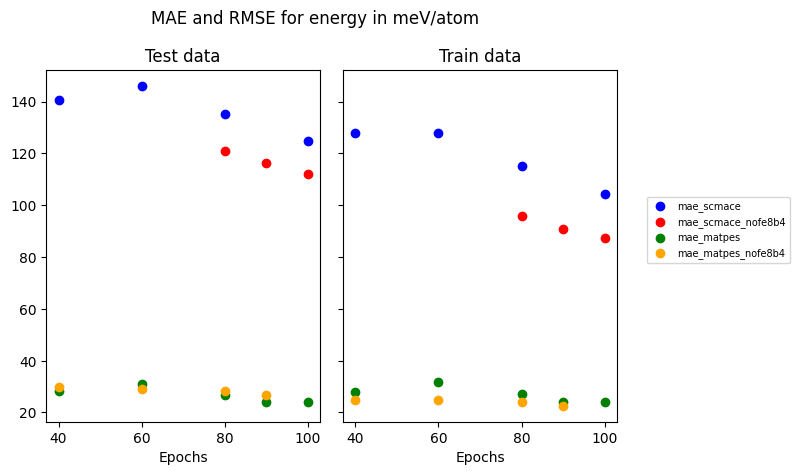

In [36]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

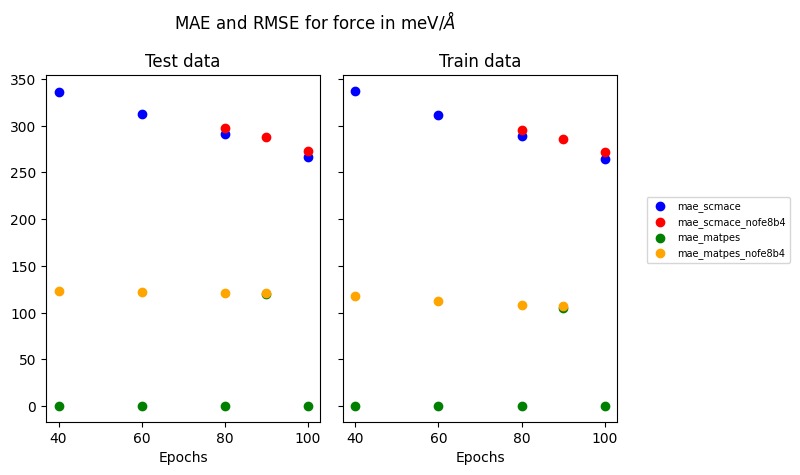

In [37]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

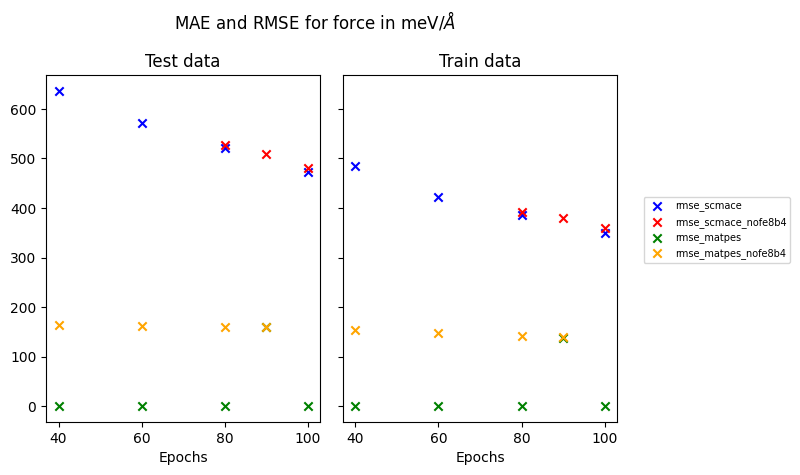

In [38]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['rmse'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

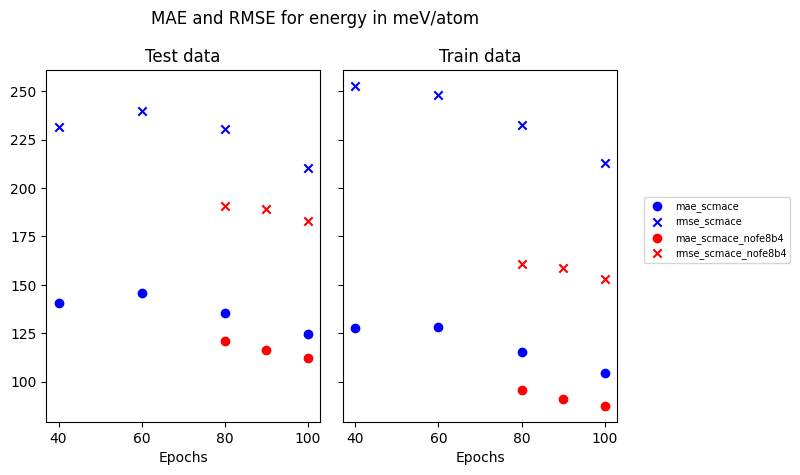

In [39]:
f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

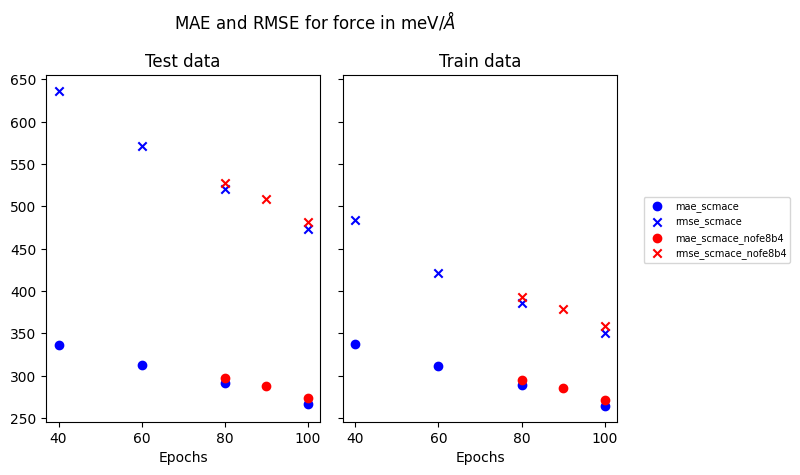

In [40]:
f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

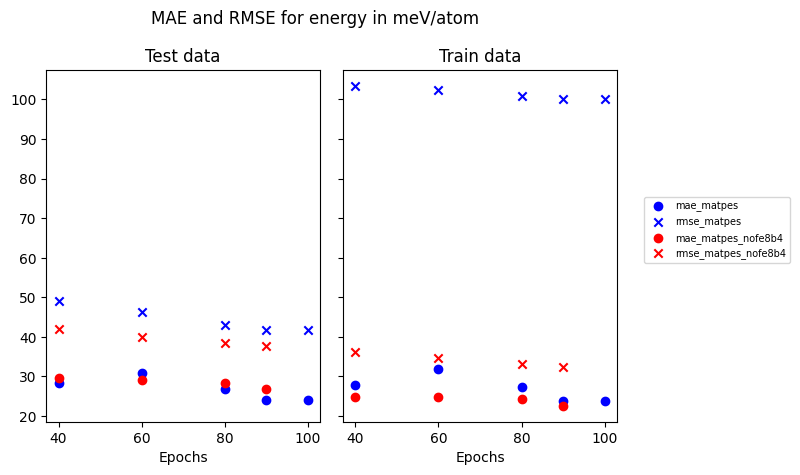

In [41]:
f.plot_global_error([matpes, matpes_nofe8b4], ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

Comparison between fine tuning and freeze tuning

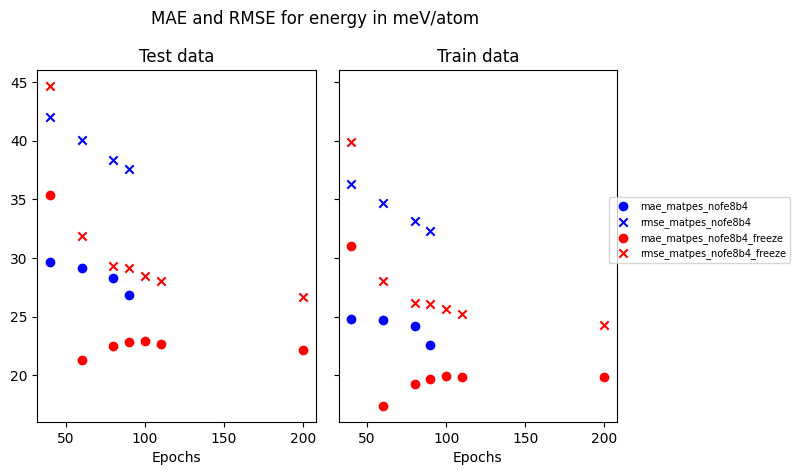

In [42]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'energy')

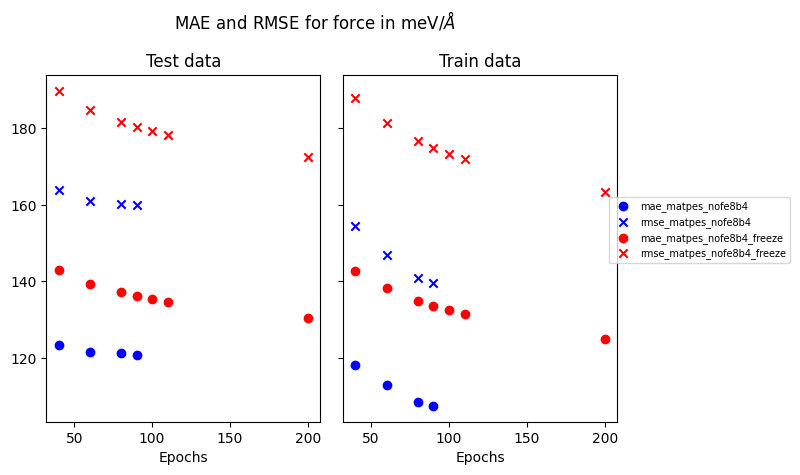

In [43]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'force')

In [44]:
matpes_nofe8b4_freeze4

,id,epochs,error,rmse,mae,r2,model
60,matpes_nofe8b4_freeze_4,440,test_energy,32.567227,25.555282,0.992658,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
61,matpes_nofe8b4_freeze_4,440,train_energy,28.369068,22.414602,0.994033,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
62,matpes_nofe8b4_freeze_4,440,test_force,162.177257,122.942449,0.996667,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
63,matpes_nofe8b4_freeze_4,440,train_force,126.781840,97.949541,0.997949,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
64,matpes_nofe8b4_freeze_4,120,test_energy,35.507368,25.943730,0.991272,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_1...
...,...,...,...,...,...,...,...
167,matpes_nofe8b4_freeze_4,360,train_force,129.044649,99.710973,0.997875,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_3...
168,matpes_nofe8b4_freeze_4,220,test_energy,35.520100,27.663029,0.991266,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_2...
169,matpes_nofe8b4_freeze_4,220,train_energy,30.985433,24.187925,0.992882,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_2...
170,matpes_nofe8b4_freeze_4,220,test_force,160.618121,121.578755,0.996731,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_2...


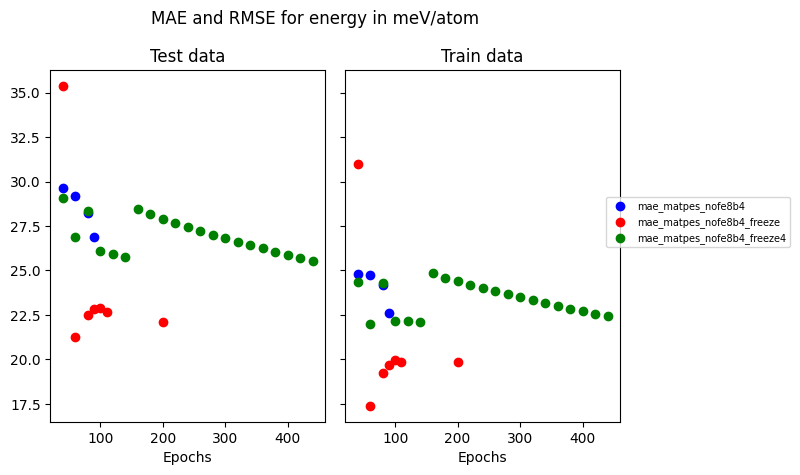

In [61]:
error_type = ['mae']
value = 'energy'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze, matpes_nofe8b4_freeze4]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze', 'matpes_nofe8b4_freeze4'], ['Test data', 'Train data'], value)

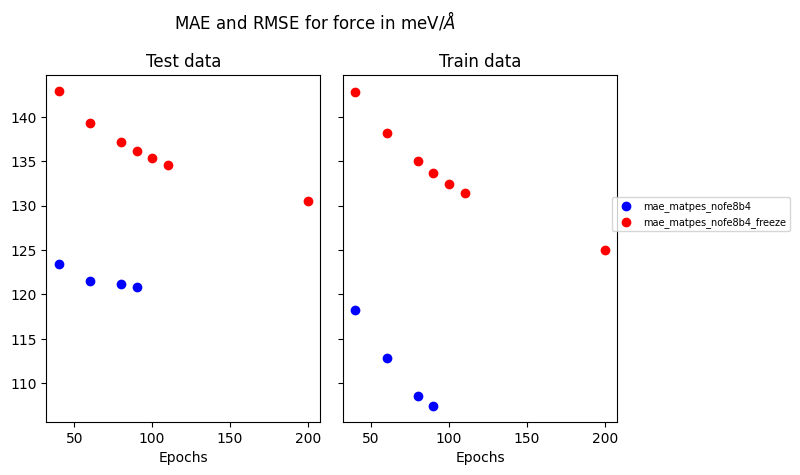

In [46]:
error_type = ['mae']
value = 'force'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], value)

In [47]:
#err_comparison = pd.concat([matpes_nofe8b4.query('epochs == 80'),matpes_nofe8b4_freeze.query('epochs == 80')])
err_comparison = pd.concat([matpes_nofe8b4, matpes_nofe8b4_freeze])
#err_comparison = err_comparison.drop(columns=['epochs'])
#err_comparison

In [48]:
#err_comparison.query('error == ["test_energy","train_energy"]')
err_comparison.query('error == "test_energy"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
156,matpes_nofe8b4_freeze,200,test_energy,26.630613,22.128958,0.995091,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_200...
100,matpes_nofe8b4_freeze,110,test_energy,27.999005,22.687344,0.994573,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_110...
68,matpes_nofe8b4_freeze,100,test_energy,28.495696,22.884726,0.994379,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...
88,matpes_nofe8b4_freeze,90,test_energy,29.152539,22.827509,0.994117,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_90_...
120,matpes_nofe8b4_freeze,80,test_energy,29.275841,22.473856,0.994067,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_80_...
136,matpes_nofe8b4_freeze,60,test_energy,31.870460,21.273370,0.992969,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_60_...
20,matpes_nofe8b4,90,test_energy,37.575629,26.868267,0.990226,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
8,matpes_nofe8b4,80,test_energy,38.374589,28.255728,0.989806,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
44,matpes_nofe8b4,60,test_energy,40.076320,29.163911,0.988881,model_rnd_e_matpes_nofe8b4_lr0.0001_60_10_test
16,matpes_nofe8b4,40,test_energy,41.982686,29.652715,0.987799,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test


In [49]:
err_comparison.query('error == "test_force"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
22,matpes_nofe8b4,90,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
10,matpes_nofe8b4,80,test_force,160.316953,121.226438,0.996743,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
46,matpes_nofe8b4,60,test_force,161.069837,121.535380,0.996712,model_rnd_e_matpes_nofe8b4_lr0.0001_60_10_test
18,matpes_nofe8b4,40,test_force,163.840934,123.462595,0.996598,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test
158,matpes_nofe8b4_freeze,200,test_force,172.530838,130.484230,0.996228,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_200...
102,matpes_nofe8b4_freeze,110,test_force,178.133890,134.540010,0.995979,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_110...
70,matpes_nofe8b4_freeze,100,test_force,179.224812,135.350202,0.995929,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...
90,matpes_nofe8b4_freeze,90,test_force,180.297008,136.086905,0.995880,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_90_...
122,matpes_nofe8b4_freeze,80,test_force,181.681786,137.098828,0.995817,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_80_...
138,matpes_nofe8b4_freeze,60,test_force,184.798005,139.316870,0.995672,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_60_...


In [50]:
err_comparison.query('error == ["test_force","train_force"]')

,id,epochs,error,rmse,mae,r2,model
10,matpes_nofe8b4,80,test_force,160.316953,121.226438,0.996743,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
11,matpes_nofe8b4,80,train_force,140.868010,108.554588,0.997468,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
18,matpes_nofe8b4,40,test_force,163.840934,123.462595,0.996598,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test
19,matpes_nofe8b4,40,train_force,154.385175,118.265340,0.996958,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test
22,matpes_nofe8b4,90,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
23,matpes_nofe8b4,90,train_force,139.439091,107.449706,0.997519,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
46,matpes_nofe8b4,60,test_force,161.069837,121.535380,0.996712,model_rnd_e_matpes_nofe8b4_lr0.0001_60_10_test
47,matpes_nofe8b4,60,train_force,146.868185,112.892891,0.997247,model_rnd_e_matpes_nofe8b4_lr0.0001_60_10_test
70,matpes_nofe8b4_freeze,100,test_force,179.224812,135.350202,0.995929,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...
71,matpes_nofe8b4_freeze,100,train_force,173.328770,132.480723,0.996166,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...


In [51]:
#matpes.query('error == ["test_energy"]').sort_values('epochs', ascending=True)

In [52]:
print(f.min(scmace, 'mae'), f.min(matpes, 'mae'))

                                                model         mae
error                                                            
test_energy   model_rnd_e_scmace_lr0.0001_100_10_test  124.774518
test_force    model_rnd_e_scmace_lr0.0001_100_10_test  266.765534
train_energy  model_rnd_e_scmace_lr0.0001_100_10_test  104.387671
train_force   model_rnd_e_scmace_lr0.0001_100_10_test  264.249749                                                 model        mae
error                                                           
test_energy   model_rnd_e_matpes_lr0.0001_100_10_test  24.019415
test_force    model_rnd_e_matpes_lr0.0001_100_10_test   0.119892
train_energy  model_rnd_e_matpes_lr0.0001_100_10_test  23.863738
train_force   model_rnd_e_matpes_lr0.0001_100_10_test   0.105124


Reading the config errors

In [53]:
df_config =f.read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [54]:
df_config.query('id == "matpes" & epochs == 100')

,id,epochs,config,n_configs,mae,rmse,error,model
62,matpes,100,Fe12B3Si3,48,72.772737,73.184691,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
63,matpes,100,Fe12Si4,12,9.839741,10.007741,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
64,matpes,100,Fe16,11,6.880569,7.642087,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
65,matpes,100,Fe34B10Si10,133,3.642926,4.661568,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
66,matpes,100,Fe8B4,8,115.094036,115.104171,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
67,matpes,100,Fe12B3Si3,132,72.800135,73.055497,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
68,matpes,100,Fe12Si4,39,9.987663,10.192224,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
69,matpes,100,Fe16,40,8.827048,10.186386,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
70,matpes,100,Fe34B10Si10,590,3.656830,4.759407,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
71,matpes,100,Fe8B4,44,173.979772,419.412618,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test


In [55]:
df.query('id == "matpes" & epochs == 100')

,id,epochs,error,rmse,mae,r2,model
28,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
29,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
30,matpes,100,test_force,0.159079,0.119892,0.996762,model_rnd_e_matpes_lr0.0001_100_10_test
31,matpes,100,train_force,0.136716,0.105124,0.997585,model_rnd_e_matpes_lr0.0001_100_10_test


In [56]:
#voy a generar un dataframe para cada modelo
scmace_config = df_config.query('id == "scmace"')
#matpes_config = df_config.query('id == "matpes"')
matpes_config = df_config.query('id == "matpes" & epochs != [500, 150]')
scmace_nofe8b4_config = df_config.query('id == "scmace_nofe8b4"')
matpes_nofe8b4_config = df_config.query('id == "matpes_nofe8b4"')

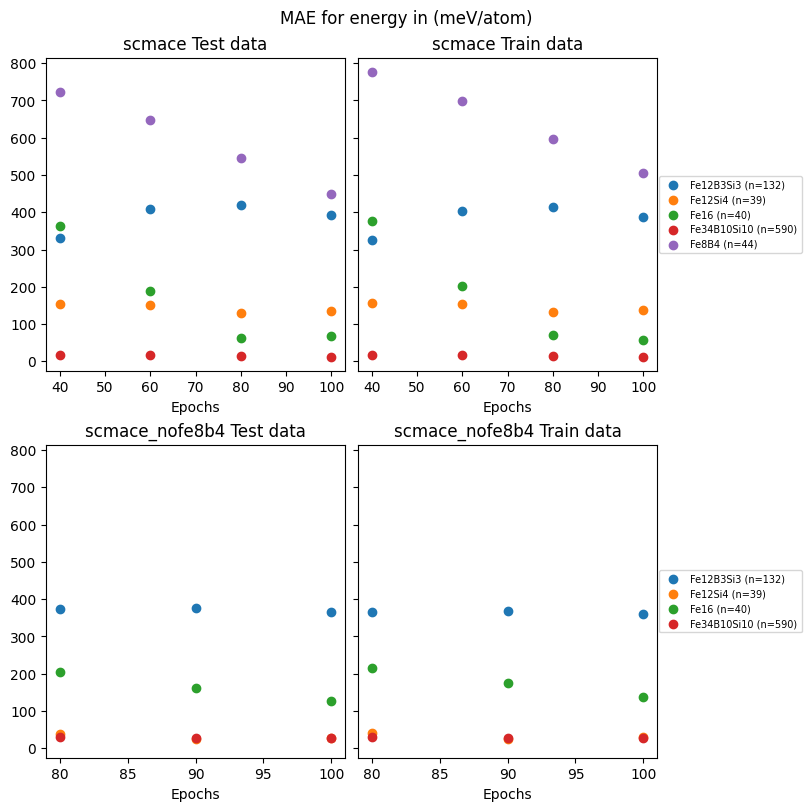

In [57]:
f.plot_config_error([scmace_config, scmace_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')

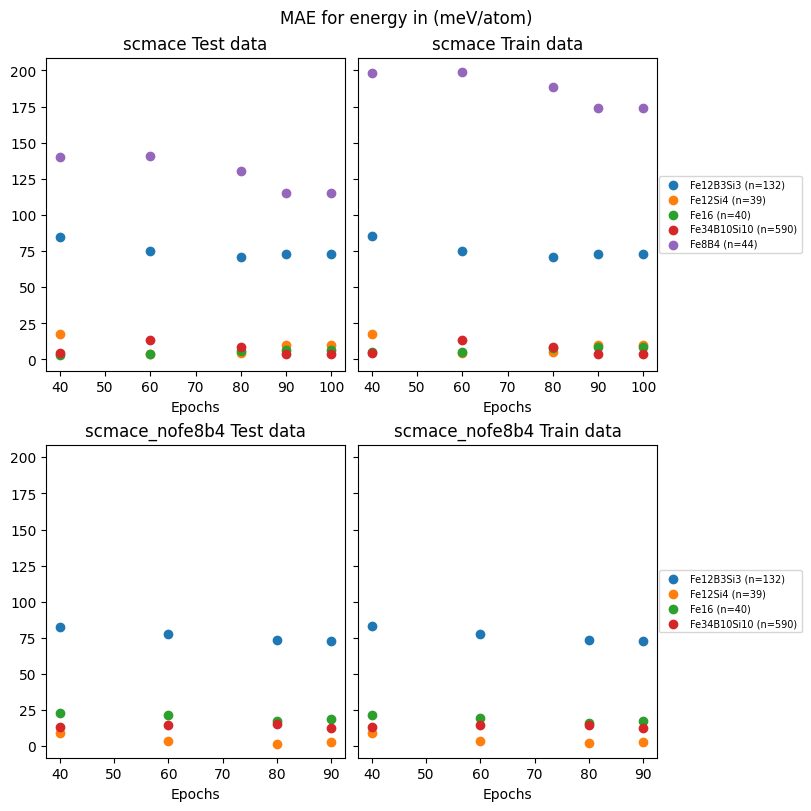

In [58]:
f.plot_config_error([matpes_config, matpes_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')